# Rain Prediction in the Melbourne Area

**Can we predict whether it will rain today using yesterday's weather?**

This notebook builds and compares two classification models (Random Forest and Logistic Regression) on daily weather observations from the Australian Bureau of Meteorology. It covers data cleaning, avoiding data leakage, feature engineering, a scikit-learn preprocessing pipeline, hyperparameter tuning with `GridSearchCV`, and model evaluation on an imbalanced target.

*Completed as the final project for the IBM **Machine Learning with Python** course (IBM Data Science Professional Certificate, Coursera).*

## The data

Daily weather observations from 49 locations across Australia, 2008 to 2017 (the "Rain in Australia" dataset on Kaggle, originally from the [Australian Bureau of Meteorology](http://www.bom.gov.au/climate/dwo/)).

Each row is one day at one location. The columns include minimum and maximum temperature, rainfall, evaporation, hours of sunshine, wind gust direction and speed, morning (9am) and afternoon (3pm) readings for wind, humidity, pressure, cloud cover and temperature, plus two Yes/No columns: `RainToday` and `RainTomorrow` (at least 1 mm of rain).

## Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

## Load the data

In [3]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
df = pd.read_csv(url)
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
df.count()

Date             145460
Location         145460
MinTemp          143975
MaxTemp          144199
Rainfall         142199
Evaporation       82670
Sunshine          75625
WindGustDir      135134
WindGustSpeed    135197
WindDir9am       134894
WindDir3pm       141232
WindSpeed9am     143693
WindSpeed3pm     142398
Humidity9am      142806
Humidity3pm      140953
Pressure9am      130395
Pressure3pm      130432
Cloud9am          89572
Cloud3pm          86102
Temp9am          143693
Temp3pm          141851
RainToday        142199
RainTomorrow     142193
dtype: int64

### Handle missing values

Sunshine, Evaporation and cloud cover are missing for a large share of rows, since not every station records them. To keep the model simple, rows with any missing value are dropped.

In [5]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 56420 entries, 6049 to 142302
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           56420 non-null  str    
 1   Location       56420 non-null  str    
 2   MinTemp        56420 non-null  float64
 3   MaxTemp        56420 non-null  float64
 4   Rainfall       56420 non-null  float64
 5   Evaporation    56420 non-null  float64
 6   Sunshine       56420 non-null  float64
 7   WindGustDir    56420 non-null  str    
 8   WindGustSpeed  56420 non-null  float64
 9   WindDir9am     56420 non-null  str    
 10  WindDir3pm     56420 non-null  str    
 11  WindSpeed9am   56420 non-null  float64
 12  WindSpeed3pm   56420 non-null  float64
 13  Humidity9am    56420 non-null  float64
 14  Humidity3pm    56420 non-null  float64
 15  Pressure9am    56420 non-null  float64
 16  Pressure3pm    56420 non-null  float64
 17  Cloud9am       56420 non-null  float64
 18  Cloud3pm       564

About 56,000 complete rows remain, so imputation isn't needed for this analysis.

In [6]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='str')

## Avoiding data leakage

Several features describe the **whole day**: `Rainfall`, `Evaporation`, `Sunshine`, `MaxTemp` and the wind gust columns aren't known until the day is over. Using today's full-day readings to predict *tomorrow* is realistic, but using them to forecast *today* is not.

To keep every feature legitimate, the question is reframed: **predict whether it rains today, using data up to and including yesterday.** That's the practical version of the problem (for example, deciding in the morning whether to bike to work). The rain columns are renamed to match the new framing.

In [7]:
df = df.rename(columns={'RainToday': 'RainYesterday',
                        'RainTomorrow': 'RainToday'
                        })

## Narrowing to one region

Rain patterns differ a lot across Australia, so a single model for all 49 locations would need to learn many local climates. Instead, the model focuses on the **Melbourne area**: Melbourne, Melbourne Airport (about 18 km away) and Watsonia (about 15 km away). `Location` is kept as a categorical feature to capture small differences between the three stations.

In [8]:
df = df[df.Location.isin(['Melbourne','MelbourneAirport','Watsonia',])]
df. info()

<class 'pandas.DataFrame'>
Index: 7557 entries, 64191 to 80997
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           7557 non-null   str    
 1   Location       7557 non-null   str    
 2   MinTemp        7557 non-null   float64
 3   MaxTemp        7557 non-null   float64
 4   Rainfall       7557 non-null   float64
 5   Evaporation    7557 non-null   float64
 6   Sunshine       7557 non-null   float64
 7   WindGustDir    7557 non-null   str    
 8   WindGustSpeed  7557 non-null   float64
 9   WindDir9am     7557 non-null   str    
 10  WindDir3pm     7557 non-null   str    
 11  WindSpeed9am   7557 non-null   float64
 12  WindSpeed3pm   7557 non-null   float64
 13  Humidity9am    7557 non-null   float64
 14  Humidity3pm    7557 non-null   float64
 15  Pressure9am    7557 non-null   float64
 16  Pressure3pm    7557 non-null   float64
 17  Cloud9am       7557 non-null   float64
 18  Cloud3pm       7557

That leaves 7,557 days, enough for a reasonable model.

## Feature engineering: season

Weather is seasonal, so a `Season` feature is extracted from `Date` (Southern Hemisphere seasons), and `Date` itself is dropped.

In [9]:
def date_to_season(date):
    month = date.month
    if (month == 12) or (month == 1) or (month == 2):
        return 'Summer'
    elif (month == 3) or (month == 4) or (month == 5):
        return 'Autumn'
    elif (month == 6) or (month == 7) or (month == 8):
        return 'Winter'
    elif (month == 9) or (month == 10) or (month == 11):
        return 'Spring'

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

df['Season'] = df['Date'].apply(date_to_season)

df = df.drop(columns='Date')

## Features and target

In [11]:
X = df.drop(columns='RainToday')
y = df['RainToday']

## How balanced is the target?

In [12]:
y.value_counts(normalize=True)


RainToday
No     0.763001
Yes    0.236999
Name: proportion, dtype: float64

- **How often it rains:** about 24% of days, roughly 1 day in 4, or about 88 days a year.
- **Baseline accuracy:** always predicting "No rain" would already be **76% accurate** while catching zero rainy days. Any useful model has to beat that, and accuracy alone will flatter it.
- **Balanced?** No. The ratio is about 3:1 in favor of dry days.
- **What that means for the approach:** use a stratified train/test split and stratified cross-validation, and judge the models on recall, precision and the confusion matrix, not just accuracy.

## Train/test split (stratified)

In [14]:
from sklearn.model_selection import train_test_split

df = df.dropna()

X = df.drop(columns='RainToday')
y = df['RainToday']

print("Rows:", df.shape[0], "| Missing in y:", y.isna().sum())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Rows: 7557 | Missing in y: 0

## Preprocessing pipeline

Numeric and categorical columns are detected automatically. Numeric features are standardized, and categorical features (location, wind directions, `RainYesterday`, `Season`) are one-hot encoded. Wrapping this in a `ColumnTransformer` and `Pipeline` means the exact same preprocessing is applied to training data, cross-validation folds and test data.

In [16]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object','str', 'category']).columns.tolist()


In [17]:
# Scale the numeric features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# One-hot encode the categoricals 
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Model 1: Random Forest

In [19]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


### Hyperparameter tuning with grid search and stratified 5-fold cross-validation

In [20]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [22]:
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', verbose=2)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Evaporation',
                                                                          'Sunshine',
                                                                          'WindGustSpeed',
                                                     

In [23]:
print("\nBest parameters found: ", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))


Best parameters found:  {'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best cross-validation score: 0.85

### Test-set performance

In [24]:
test_score = grid_search.score(X_test, y_test)
print("Test set score: {:.2f}".format(test_score))


Test set score: 0.84

The model is right on about 84% of unseen days, compared with the 76% baseline. The classification report and confusion matrix show where it succeeds and where it doesn't.

In [25]:
y_pred = grid_search.predict(X_test)


In [26]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.95      0.90      1154
         Yes       0.75      0.51      0.61       358

    accuracy                           0.84      1512
   macro avg       0.81      0.73      0.76      1512
weighted avg       0.84      0.84      0.83      1512


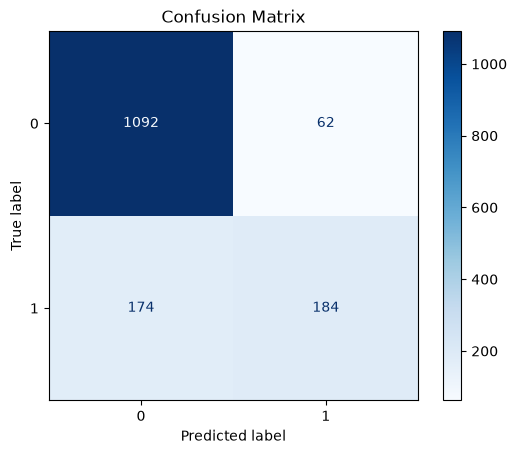

In [27]:
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


### Interpreting the Random Forest results

| | Predicted No | Predicted Yes |
|---|---|---|
| **Actually No** | 1,092 | 62 |
| **Actually Yes** | 174 | 184 |

- **Accuracy:** 84%, about 8 percentage points above the 76% baseline.
- **True positive rate (recall for rain):** 184 / (184 + 174) = **51%**. The model catches about half of rainy days and misses the other half.
- **Precision for rain:** 75%. When it predicts rain, it's right three times out of four, with only 62 false alarms.

The model is strong on dry days but misses many rainy ones, a typical effect of the 3:1 class imbalance.

## Feature importance

The Random Forest's importances are matched back to feature names. Categorical features appear under their one-hot encoded names (for example `RainYesterday_Yes`).

In [28]:
feature_importances = grid_search.best_estimator_['classifier'].feature_importances_


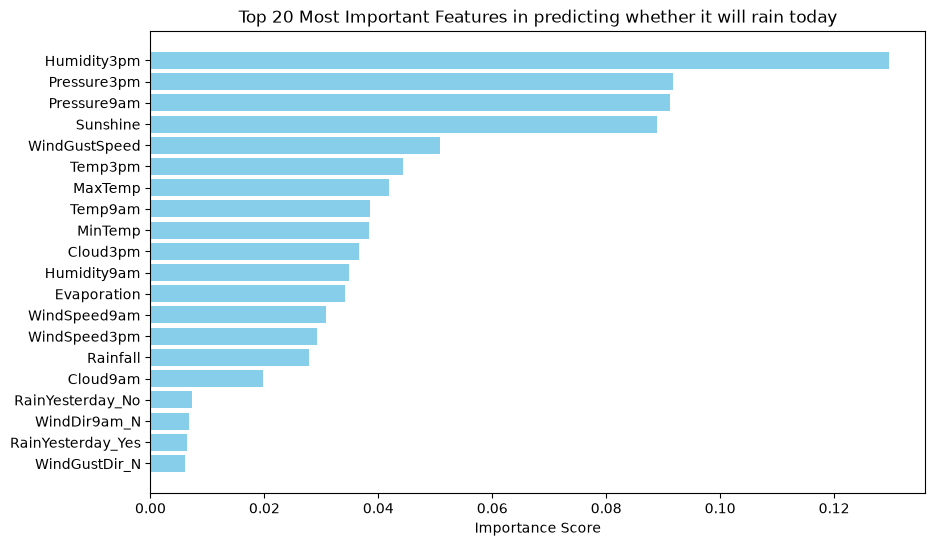

In [29]:
# Combine numeric and categorical feature names
feature_names = numeric_features + list(grid_search.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

feature_importances = grid_search.best_estimator_['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

N = 20  # Change this number to display more or fewer features
top_features = importance_df.head(N)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.title(f'Top {N} Most Important Features in predicting whether it will rain today')
plt.xlabel('Importance Score')
plt.show()

**Afternoon humidity (`Humidity3pm`) is the strongest predictor** by a wide margin, followed by afternoon and morning pressure and hours of sunshine. Wind direction contributes very little: once it's split into 16 one-hot compass columns, each piece carries almost no signal. Correlated features (such as the two humidity readings) can share credit, so a lower score doesn't automatically mean a feature is useless.

## Model 2: Logistic Regression

The same pipeline and grid search are reused with the classifier swapped out, tuning the regularization penalty and whether to re-weight the classes.

In [32]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [33]:

# Replace RandomForestClassifier with LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

# Update the model's estimator to use the new pipeline
grid_search.estimator = pipeline

# Define a new grid with Logistic Regression parameters
param_grid = {
    # 'classifier__n_estimators': [50, 100],
    # 'classifier__max_depth': [None, 10, 20],
    # 'classifier__min_samples_split': [2, 5],
    'classifier__solver': ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced']
}

grid_search.param_grid = param_grid

# Fit the updated pipeline with LogisticRegression
model = grid_search
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

### Logistic Regression results

              precision    recall  f1-score   support

          No       0.86      0.93      0.89      1154
         Yes       0.68      0.51      0.58       358

    accuracy                           0.83      1512
   macro avg       0.77      0.72      0.74      1512
weighted avg       0.82      0.83      0.82      1512


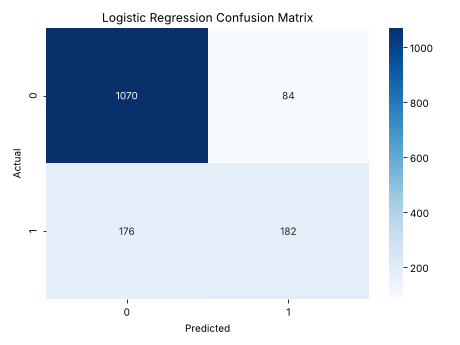

In [34]:
print(classification_report(y_test, y_pred))

# Generate the confusion matrix 
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

## Conclusions

| Model | Accuracy | True positive rate (rain) | Precision (rain) | False alarms |
|---|---|---|---|---|
| Always predict "No rain" | 76% | 0% | n/a | 0 |
| Logistic Regression | 83% | 51% (182 / 358) | 68% | 84 |
| **Random Forest** | **84%** | **51% (184 / 358)** | **75%** | **62** |

1. **Accuracy:** both models beat the 76% baseline, but only by 7 to 8 points. Because the data is imbalanced, accuracy overstates how well either model predicts rain.
2. **True positive rate:** both catch about half of rainy days (51%), so neither is yet a reliable rain predictor.
3. **Better model:** the **Random Forest** is slightly ahead: marginally higher accuracy and recall, and noticeably fewer false alarms (62 vs. 84). The gap is small.

## Ideas to improve it

- Tune for **recall or F1** instead of accuracy, so the grid search rewards catching rain.
- Use `class_weight='balanced'` or resampling to counter the imbalance.
- Adjust the decision threshold to trade some precision for higher recall.
- Use more data: impute missing values instead of dropping rows, or add nearby stations and more years.
- Add lag features such as the 24-hour change in pressure or humidity.